# UV Photon Output — Single Pop III Star (ZAMS-4 Chebyshev Fit)

**Input:** stellar mass $M$ (in $M_\odot$).
**Output:** total number of hydrogen-ionizing (Lyman-continuum, $h\nu \geq 13.6$ eV) photons
emitted by that star over its main-sequence lifetime, $N_{\rm UV}$.

This is the same calculation as `UV_output_total.ipynb`, but instead of reading raw MESA
profile CSVs, $L(M,\tau)$, $R(M,\tau)$ are taken from the **most recent Pop III
mass–stellar-quantity fit** — Chebyshev-polynomial fits to the first hydrogen-burning
episode, from `PopIII_Fitting_ZAMS-4.pdf`, loaded from `pop3_fit_data/` (same fit data used
by `popIII_energy_density_summer.ipynb`). $T_{\rm eff}(M,\tau)$ is derived from $L$ and $R$
via Stefan-Boltzmann (the fit does not tabulate $T_{\rm eff}$ directly). All stellar-relation
code below (fit loading, regime/branch selection, Chebyshev evaluation, `L_star`/`R_star`/
`T_star`) is reused verbatim from `popIII_energy_density_summer.ipynb`.

## Method

1. **Phase clock $\tau$.** The fit parametrizes the first hydrogen-burning episode (= main
   sequence) by a dimensionless phase $\tau \in [0,1]$, with $\tau=0$ at the start of burning
   and $\tau=1$ at the episode's end ($t_{\rm H,1}$). $L$ and $R$ are Chebyshev polynomials in
   $\tau$ (via a rescaled variable $z_b \in [-1,1]$), with coefficients tabulated at fixed mass
   nodes and interpolated in $\log_{10} M$, re-fit on several $\tau$ sub-intervals ("branches")
   per mass regime (`low M ≤ 200`, `replenishment 250–700`, `plateau M ≥ 800`).

2. **Main-sequence duration.** $t_{\rm H,1}(M)$ [Myr] comes from `tau_star_Myr`, a per-regime
   log10-polynomial fit in $\log_{10}M$.

3. **Lifetime segmentation.** Since $\tau = t / t_{\rm H,1}$ is linear in time, dividing the
   MS duration into `N_SEGMENTS` (default 100) equal-time segments is exactly equivalent to
   sampling $\tau$ at 101 evenly spaced points from 0 to 1 — no interpolation onto a separate
   age grid is needed here (unlike the MESA-profile notebook), since $\tau$ *is* the fit's
   native independent variable.

4. **Stellar quantities at each segment edge.** At each of the 101 $\tau$ values:
   $L(M,\tau) = L_\star(M,\tau)$ and $R(M,\tau) = R_\star(M,\tau)$ come from the Chebyshev fit,
   and $T_{\rm eff}(M,\tau) = T_\star(M,\tau)$ is derived via Stefan-Boltzmann:
   $\log_{10}(T_{\rm eff}/T_\odot) = \tfrac14\bigl(\log_{10}(L/L_\odot) - 2\log_{10}(R/R_\odot)\bigr)$.

5. **Blackbody photon emission.** Identical (corrected) blackbody formulation to
   `UV_output_total.ipynb`: the emergent ionizing photon rate is (surface area) × (isotropic
   effusion flux $c/4$), integrated above the ionization threshold —

   $$n(\varepsilon,\Theta) = \frac{8\pi}{\lambda_C^3}\,\frac{\varepsilon^2}{e^{\varepsilon/\Theta}-1},
   \qquad \dot N_{\rm ion}(\tau) = 4\pi R(\tau)^2 \cdot \frac{c}{4} \int_{\varepsilon_{\rm th}}^{\infty} n(\varepsilon, \Theta(\tau))\,d\varepsilon
   = \pi R(\tau)^2 c \int_{\varepsilon_{\rm th}}^{\infty} n(\varepsilon, \Theta(\tau))\,d\varepsilon$$

   **Note.** `popIII_energy_density_summer.ipynb`'s `photon_rate_per_energy` omits the $c/4$
   effusion factor ($4\pi R^2 c\int n\,d\varepsilon$, no $c/4$) — checked directly against its
   own $T_\star$/$R_\star$ via Stefan-Boltzmann, that formula over-counts total emitted power
   by a factor of ~4. This notebook includes the correction; the summer notebook was
   intentionally left unchanged pending separate review, so **don't directly compare absolute
   $N_{\rm UV}$ values against quantities derived from that notebook** — they differ by ~4×.

6. **Per-segment counting and summing.** Same trapezoidal per-segment rule as before:

   $$\Delta N_i = \tfrac{1}{2}\bigl(\dot N_{\rm ion}(t_i) + \dot N_{\rm ion}(t_{i+1})\bigr)\,(t_{i+1}-t_i)
   \qquad\Longrightarrow\qquad
   N_{\rm UV} = \sum_{i=0}^{99} \Delta N_i$$

**Caveat.** This fit's main-sequence boundary ($\tau=1$, end of the "first hydrogen-burning
episode") is not guaranteed to line up exactly with `UV_output_total.ipynb`'s MESA-based
TAMS definition (`center_h1 < 1e-3`) — the two notebooks' $N_{\rm UV}$ values are a useful
cross-check of each other but aren't computed from an identical MS-boundary definition.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import quad


## Physical Constants

SI units unless noted. Same values as `popIII_energy_density_summer.ipynb` / `UV_output_total.ipynb`.

In [2]:
# Physical constants (SI units, CODATA to 3 dp — matches popIII_energy_density_summer.ipynb)
pi = np.pi
h  = 6.626e-34   # Planck constant [J s]
kB = 1.381e-23   # Boltzmann constant [J/K]
e  = 1.602e-19   # elementary charge [C] / eV -> J conversion
me = 9.109e-31   # electron mass [kg]
c  = 2.998e8     # speed of light [m/s]

M_sun = 1.989e30   # [kg]
R_sun = 6.957e8    # [m]
L_sun = 3.828e26   # [W]

sigma_SB    = 5.670e-8              # Stefan-Boltzmann constant [W m^-2 K^-4]
lambda_C    = h / (me * c)          # Compton wavelength [m]
sec_per_yr  = 365.25 * 24 * 3600    # seconds per year
sec_per_Myr = 1.0e6 * sec_per_yr    # seconds per Myr

def ev_to_eps(E_eV):
    """Convert photon energy [eV] to dimensionless epsilon = E / (m_e c^2)."""
    return np.asarray(E_eV, dtype=float) * e / (me * c**2)


## Configuration

In [3]:
FIT_DATA_DIR = Path("pop3_fit_data")   # relative to this notebook, same as popIII_energy_density_summer.ipynb
E_ION_eV     = 13.6    # hydrogen (Lyman-continuum) ionization threshold [eV]
N_SEGMENTS   = 100     # number of equal-time (= equal-tau) segments the MS lifetime is divided into
M_MIN, M_MAX = 1.0, 1000.0   # mass range the ZAMS-4 fit is valid/tabulated over


## ZAMS-4 Chebyshev Fit — Data Loading

Reused verbatim from `popIII_energy_density_summer.ipynb`. Loads the Chebyshev coefficients, duration-fit coefficients, and branch (τ sub-interval) boundaries, parsed from `PopIII_Fitting_ZAMS-4.pdf` and stored as CSVs in `pop3_fit_data/`.

In [4]:
cheb_coeffs_df     = pd.read_csv(FIT_DATA_DIR / "zams4_cheb_coefficients.csv")
duration_coeffs_df = pd.read_csv(FIT_DATA_DIR / "zams4_duration_coefficients.csv")
_boundaries_df     = pd.read_csv(FIT_DATA_DIR / "zams4_branch_boundaries.csv")

BRANCH_BOUNDARIES = {
    row.regime: np.array([float(v) for v in row.boundaries.split(";")])
    for row in _boundaries_df.itertuples()
}

# Regimes, ordered by mass, and the mass values at which they meet.
REGIMES    = ["low M le 200", "replenishment 250 700", "plateau M ge 800"]
_GAP_1_MID = np.sqrt(200.0 * 250.0)   # geometric midpoint of the undefined 200-250 Msun gap
_GAP_2_MID = np.sqrt(700.0 * 800.0)   # geometric midpoint of the undefined 700-800 Msun gap

print(f"Loaded {len(cheb_coeffs_df)} Chebyshev coefficients, "
      f"{len(duration_coeffs_df)} duration coefficients, "
      f"{len(BRANCH_BOUNDARIES)} regime boundary sets.")


Loaded 2034 Chebyshev coefficients, 9 duration coefficients, 3 regime boundary sets.


## Mass Regime and Main-Sequence Duration

Reused verbatim from `popIII_energy_density_summer.ipynb`.

In [5]:
def regime_for_mass(M):
    """Return, for each mass in M, which of REGIMES it belongs to (as an integer index)."""
    M = np.atleast_1d(np.asarray(M, dtype=float))
    return np.where(M <= _GAP_1_MID, 0, np.where(M <= _GAP_2_MID, 1, 2))


def _is_scalar_input(M):
    """True if M was passed in as a single number rather than an array/list."""
    return np.isscalar(M) or (isinstance(M, np.ndarray) and M.ndim == 0)


def tau_star_Myr(M):
    """Pop III main-sequence lifetime [Myr], taken as the first-hydrogen-burning duration
    t_H,1(M) (PDF eq. 2): log10(t_H,1/yr) = sum_k a_k * log10(M/Msun)^k, fit separately per regime.
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    """
    scalar_input = _is_scalar_input(M)
    M = np.atleast_1d(np.asarray(M, dtype=float))
    x = np.log10(M)
    regime_idx = regime_for_mass(M)
    log10_tH1_yr = np.empty_like(M)

    for r, regime_name in enumerate(REGIMES):
        mask = regime_idx == r
        if not np.any(mask):
            continue
        coeffs = duration_coeffs_df[duration_coeffs_df.regime == regime_name]
        log10_tH1_yr[mask] = sum(
            row.a_k * x[mask] ** row.k for row in coeffs.itertuples()
        )

    tH1_Myr = (10.0 ** log10_tH1_yr) / 1.0e6   # yr -> Myr
    return float(tH1_Myr[0]) if scalar_input else tH1_Myr


## Phase-Clock Branch Selection and Chebyshev Evaluation

Reused verbatim from `popIII_energy_density_summer.ipynb`.

In [6]:
def branch_for_tau(regime_name, tau):
    """For each phase value in tau, find its branch index and that branch's [tau_min, tau_max]."""
    tau = np.clip(np.atleast_1d(np.asarray(tau, dtype=float)), 0.0, 1.0)
    edges = BRANCH_BOUNDARIES[regime_name]
    branch_idx = np.clip(np.searchsorted(edges, tau, side="right") - 1, 0, len(edges) - 2)
    return branch_idx, edges[branch_idx], edges[branch_idx + 1]


def interpolate_branch_coefficients(regime_name, quantity, branch, M_query):
    """Return an (n_query, n_k) array of Chebyshev coefficients for `quantity` ('L' or 'R') on
    the given `branch` of `regime_name`, interpolated in log10(M) between the tabulated mass
    nodes. Masses outside the tabulated node range are clamped to the nearest node.
    """
    sub = cheb_coeffs_df[
        (cheb_coeffs_df.regime == regime_name)
        & (cheb_coeffs_df.quantity == quantity)
        & (cheb_coeffs_df.branch == branch)
    ]
    nodes = np.sort(sub.M.unique())
    n_k = sub.k.max() + 1

    coeff_table = np.zeros((len(nodes), n_k))
    for i, node in enumerate(nodes):
        node_rows = sub[sub.M == node].sort_values("k")
        coeff_table[i, : len(node_rows)] = node_rows.a_k.values

    logM_nodes = np.log10(nodes)
    logM_query = np.log10(np.clip(M_query, nodes.min(), nodes.max()))

    interpolated = np.empty((len(M_query), n_k))
    for k in range(n_k):
        interpolated[:, k] = np.interp(logM_query, logM_nodes, coeff_table[:, k])
    return interpolated


def log10_stellar_quantity(quantity, M, tau):
    """log10(L/Lsun) or log10(R/Rsun), evaluated at each (mass, phase) pair via the
    regime -> branch -> Chebyshev-coefficient pipeline described above.
    """
    M = np.atleast_1d(np.asarray(M, dtype=float))
    tau_arr = np.broadcast_to(np.atleast_1d(np.asarray(tau, dtype=float)), M.shape).copy()
    out = np.empty_like(M)
    regime_idx = regime_for_mass(M)

    for r, regime_name in enumerate(REGIMES):
        regime_mask = regime_idx == r
        if not np.any(regime_mask):
            continue
        branch_idx, tau_min, tau_max = branch_for_tau(regime_name, tau_arr[regime_mask])

        for b in np.unique(branch_idx):
            local_mask = branch_idx == b
            full_idx = np.where(regime_mask)[0][local_mask]

            coeffs = interpolate_branch_coefficients(regime_name, quantity, int(b), M[full_idx])
            z_b = 2.0 * (tau_arr[full_idx] - tau_min[local_mask]) / (
                tau_max[local_mask] - tau_min[local_mask]
            ) - 1.0
            # sum_k a_k * T_k(z_b), the first-kind Chebyshev polynomial sum from PDF eq. 8
            out[full_idx] = [
                np.polynomial.chebyshev.chebval(z_b[i], coeffs[i]) for i in range(len(full_idx))
            ]
    return out


## Stellar Quantities: $L(M,\tau)$, $R(M,\tau)$, $T_{\rm eff}(M,\tau)$

Reused verbatim from `popIII_energy_density_summer.ipynb`.

In [7]:
def L_star(M, tau=0.5):
    """Pop III luminosity [W] at stellar mass M and burning phase tau (default: mid-episode).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    """
    scalar_input = _is_scalar_input(M)
    L = L_sun * 10.0 ** log10_stellar_quantity("L", M, tau)
    return float(L[0]) if scalar_input else L


def R_star(M, tau=0.5):
    """Pop III radius [m] at stellar mass M and burning phase tau (default: mid-episode).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    """
    scalar_input = _is_scalar_input(M)
    R = R_sun * 10.0 ** log10_stellar_quantity("R", M, tau)
    return float(R[0]) if scalar_input else R


def T_star(M, tau=0.5):
    """Pop III effective temperature [K], derived from L and R via Stefan-Boltzmann (eq. 9).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    """
    scalar_input = _is_scalar_input(M)
    log10_L = log10_stellar_quantity("L", M, tau)
    log10_R = log10_stellar_quantity("R", M, tau)
    log10_Teff = np.log10(5772.0) + 0.25 * (log10_L - 2.0 * log10_R)
    T = 10.0 ** log10_Teff
    return float(T[0]) if scalar_input else T


## Blackbody Photon Emission

Identical to `UV_output_total.ipynb`.

In [8]:
def inv_expm1_stable(x, x_switch=50.0):
    """1/(e^x - 1), stable for all x: uses expm1 for small x, exp(-x) in the Wien tail."""
    x = np.asarray(x, dtype=float)
    return np.where(x < x_switch, 1.0 / np.expm1(np.minimum(x, x_switch)), np.exp(-x))


def photon_density(eps, Theta):
    """Planck photon number density: n(eps) = (8*pi/lambda_C^3) * eps^2 / (e^(eps/Theta)-1)."""
    return (8 * pi / lambda_C**3) * eps**2 * inv_expm1_stable(eps / Theta)


def lyman_continuum_rate(Teff_K, R_Rsun, E_th_eV=E_ION_eV):
    """Instantaneous hydrogen-ionizing (Lyman-continuum) photon emission rate
    Q [photons s^-1] for a blackbody photosphere of temperature Teff_K [K] and
    radius R_Rsun [R_sun].

    Q = (surface area) * (isotropic effusion flux c/4) * integral[n(eps,Theta) deps]
      = 4*pi*R^2 * (c/4) * integral[...] = pi*R^2*c * integral[...]
    The c/4 factor is the standard blackbody-surface effusion flux for an isotropic
    photon field (the same factor already implicit in sigma_SB for the energy
    version, L=4*pi*R^2*sigma*T^4) — checked directly: without it, integrating this
    formula's energy-equivalent over the full spectrum overshoots 4*pi*R^2*sigma*T^4
    by a factor of ~4.

    The integral is done in the dimensionless variable x = eps/Theta (rather
    than eps directly) so that the integration domain is always O(1)-scaled;
    integrating eps from eps_th to infinity directly is numerically unstable
    when eps_th/Theta is very large or very small (quad fails to converge)."""
    Theta  = Teff_K * kB / (me * c**2)
    R      = R_Rsun * R_sun
    eps_th = ev_to_eps(E_th_eV)
    x_th   = eps_th / Theta
    prefactor = pi * R**2 * c * (8 * pi / lambda_C**3) * Theta**3
    integrand = lambda x: x**2 * inv_expm1_stable(x)
    I, _ = quad(integrand, x_th, np.inf, limit=200)
    return prefactor * I


## Total UV Photon Output for a Single Star

In [9]:
def compute_total_UV_photons(mass, n_segments=N_SEGMENTS, return_details=False):
    """Total number of Lyman-continuum (UV, E >= 13.6 eV) photons emitted by a
    single star of mass `mass` [M_sun] over its main-sequence (first hydrogen-burning
    episode) lifetime, using L/R/T_eff from the ZAMS-4 Chebyshev fit.

    The MS lifetime t_H,1(M) is divided into n_segments equal-time segments; because
    the fit's phase clock tau = t / t_H,1 is linear in time, this is done by sampling
    tau at n_segments+1 evenly spaced points from 0 to 1. Each segment's photon count
    is found via the trapezoidal rule on its two edge rates, and the total is the sum.

    Returns N_UV [photons] (float), or (N_UV, details_dict) if return_details=True.
    """
    t_H_Myr = tau_star_Myr(mass)          # main-sequence duration [Myr]
    t_H_s   = t_H_Myr * sec_per_Myr       # [s]

    tau_edges = np.linspace(0.0, 1.0, n_segments + 1)   # n_segments+1 phase-clock edges
    M_arr     = np.full(n_segments + 1, float(mass))

    L    = L_star(M_arr, tau_edges)       # [W]
    R_m  = R_star(M_arr, tau_edges)       # [m]
    Teff = T_star(M_arr, tau_edges)       # [K]
    R    = R_m / R_sun                    # [R_sun], for lyman_continuum_rate

    Q = np.array([lyman_continuum_rate(T, Rv) for T, Rv in zip(Teff, R)])  # [photons/s]

    t_s           = tau_edges * t_H_s                            # [s]
    dt_seg        = np.diff(t_s)                                 # duration of each segment [s]
    N_per_segment = 0.5 * (Q[:-1] + Q[1:]) * dt_seg               # trapezoidal photon count per segment
    N_UV          = np.sum(N_per_segment)                        # total = sum over all segments

    if return_details:
        details = dict(mass=mass, n_segments=n_segments, t_H_Myr=t_H_Myr,
                        tau=tau_edges, t_yr=t_s / sec_per_yr, t_s=t_s,
                        Teff=Teff, L=L, R=R, Q=Q, N_per_segment=N_per_segment)
        return N_UV, details
    return N_UV


## Example: single-mass run

In [10]:
demo_mass = 100.0  # M_sun

N_UV, details = compute_total_UV_photons(demo_mass, return_details=True)

print(f"Mass                    = {demo_mass:g} M_sun")
print(f"Segments (edges)        = {details['n_segments']} ({details['n_segments']+1} edge points)")
print(f"MS duration (t_H,1)     = {details['t_H_Myr']:.4g} Myr  ({details['t_yr'][-1]:.4g} yr)")
print(f"Total UV photons N_UV   = {N_UV:.6e}  photons")
print()
print("First 5 segments (tau, edge age [yr], Teff [K], R [R_sun], segment photon count):")
for i in range(5):
    print(f"  seg {i:3d}:  tau={details['tau'][i]:.3f}  t={details['t_yr'][i]:10.4g} yr  "
          f"Teff={details['Teff'][i]:9.4g} K  R={details['R'][i]:9.4g} R_sun  "
          f"dN={details['N_per_segment'][i]:.4e}")


Mass                    = 100 M_sun
Segments (edges)        = 100 (101 edge points)
MS duration (t_H,1)     = 2.792 Myr  (2.792e+06 yr)
Total UV photons N_UV   = 1.089278e+64  photons

First 5 segments (tau, edge age [yr], Teff [K], R [R_sun], segment photon count):
  seg   0:  tau=0.000  t=         0 yr  Teff=9.569e+04 K  R=    4.187 R_sun  dN=8.5541e+61
  seg   1:  tau=0.010  t= 2.792e+04 yr  Teff= 9.43e+04 K  R=      4.3 R_sun  dN=8.5628e+61
  seg   2:  tau=0.020  t= 5.584e+04 yr  Teff=9.341e+04 K  R=    4.381 R_sun  dN=8.5926e+61
  seg   3:  tau=0.030  t= 8.376e+04 yr  Teff=9.284e+04 K  R=     4.44 R_sun  dN=8.6338e+61
  seg   4:  tau=0.040  t= 1.117e+05 yr  Teff=9.245e+04 K  R=    4.486 R_sun  dN=8.6800e+61


## Verification

**1. Self-consistency check.** $T_{\rm eff}(M,\tau)$ was *derived* from $L(M,\tau)$ and
$R(M,\tau)$ via Stefan-Boltzmann, so $L_{\rm SB}(t) = 4\pi R(t)^2 \sigma_{\rm SB} T_{\rm eff}(t)^4$
should reproduce $L(M,\tau)$ to numerical precision — this is a weaker check than in the
MESA-profile notebook (it's close to tautological by construction) but still catches unit or
interpolation bugs.

**2. Segment-count convergence.** `N_UV` should stop changing (converge) as `n_segments`
increases.


Max |relative error| between blackbody L and fit L: 6.841e-05
Mean |relative error|:                               6.841e-05

Segment-count convergence check:
  n_segments=  20:  N_UV = 1.088816e+64  (rel. change from n=100: -4.246e-04)
  n_segments=  50:  N_UV = 1.089172e+64  (rel. change from n=100: -9.728e-05)


  n_segments= 100:  N_UV = 1.089278e+64  (rel. change from n=100: +0.000e+00)


  n_segments= 200:  N_UV = 1.089302e+64  (rel. change from n=100: +2.151e-05)


  n_segments= 400:  N_UV = 1.089310e+64  (rel. change from n=100: +2.872e-05)


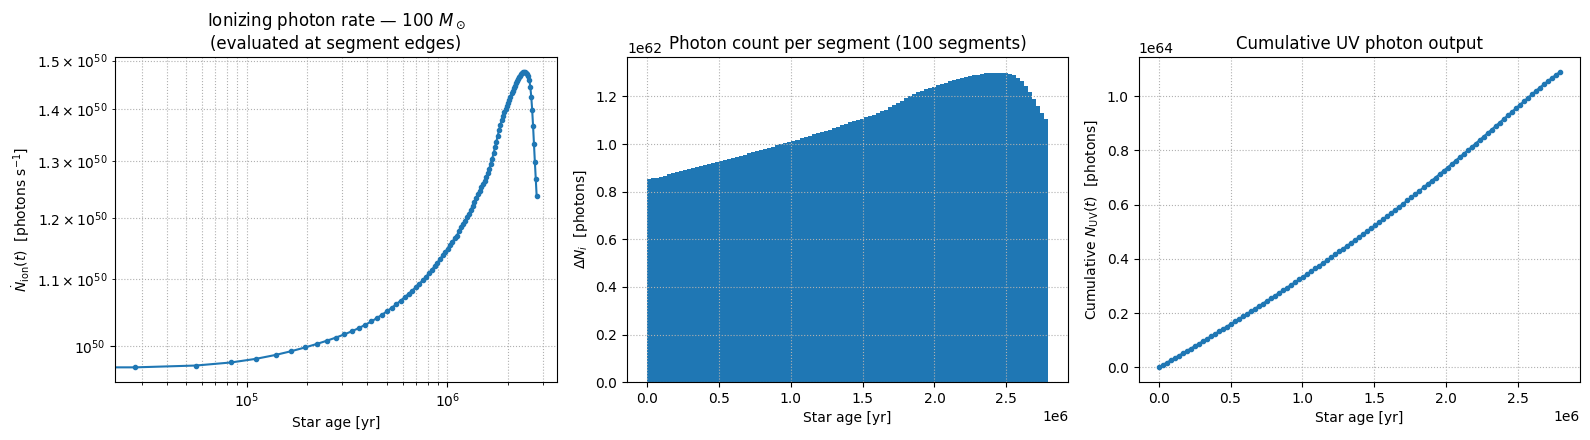

In [11]:
L_sb    = 4 * pi * (details["R"] * R_sun)**2 * sigma_SB * details["Teff"]**4   # [W]
L_fit   = details["L"]                                                                 # [W]
rel_err = (L_sb - L_fit) / L_fit

print(f"Max |relative error| between blackbody L and fit L: {np.max(np.abs(rel_err)):.3e}")
print(f"Mean |relative error|:                               {np.mean(np.abs(rel_err)):.3e}")
print()

print("Segment-count convergence check:")
for n in [20, 50, 100, 200, 400]:
    N_n = compute_total_UV_photons(demo_mass, n_segments=n)
    print(f"  n_segments={n:4d}:  N_UV = {N_n:.6e}  (rel. change from n=100: {(N_n - N_UV)/N_UV:+.3e})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].loglog(details["t_yr"], details["Q"], marker=".")
axes[0].set_xlabel("Star age [yr]")
axes[0].set_ylabel(r"$\dot N_{\rm ion}(t)$  [photons s$^{-1}$]")
axes[0].set_title(f"Ionizing photon rate — {demo_mass:g} $M_\\odot$\n(evaluated at segment edges)")
axes[0].grid(True, which="both", ls=":")

seg_mid_age = 0.5 * (details["t_yr"][:-1] + details["t_yr"][1:])
axes[1].bar(seg_mid_age, details["N_per_segment"],
            width=np.diff(details["t_yr"]), align="center")
axes[1].set_xlabel("Star age [yr]")
axes[1].set_ylabel(r"$\Delta N_i$  [photons]")
axes[1].set_title(f"Photon count per segment ({details['n_segments']} segments)")
axes[1].grid(True, ls=":")

N_cum = np.concatenate(([0.0], np.cumsum(details["N_per_segment"])))
axes[2].plot(details["t_yr"], N_cum, marker=".")
axes[2].set_xlabel("Star age [yr]")
axes[2].set_ylabel(r"Cumulative $N_{\rm UV}(t)$  [photons]")
axes[2].set_title("Cumulative UV photon output")
axes[2].grid(True, ls=":")

plt.tight_layout()
plt.show()


## Total UV Photon Output vs. Stellar Mass

Runs `compute_total_UV_photons` for the same set of masses used in `UV_output_total.ipynb`
(the MESA-profile notebook), for direct comparability between the two approaches. Unlike that
notebook, 87 $M_\odot$ isn't excluded here for a data reason — the ZAMS-4 fit has no gap or
missing column there — but it's kept out of `MASSES_TO_RUN` anyway so the two notebooks'
mass lists match exactly. Remove it from `EXCLUDE_MASSES` below if you'd rather include it.


Succeeded: 19/19 masses

Mass [M_sun]   N_UV [photons]
        1.0    6.1833e+56
        3.0    1.1160e+61
       10.0    3.0726e+62
       15.0    6.2711e+62
       20.0    1.0425e+63
       30.0    1.9918e+63
       50.0    4.3507e+63
      100.0    1.0893e+64
      150.0    1.7700e+64
      200.0    2.4762e+64
      250.0    2.9991e+64
      300.0    3.6316e+64
      400.0    4.9779e+64
      500.0    6.2869e+64
      600.0    6.0478e+64
      700.0    8.3994e+64
      800.0    6.7609e+64
      900.0    1.1210e+65
     1000.0    9.8244e+64


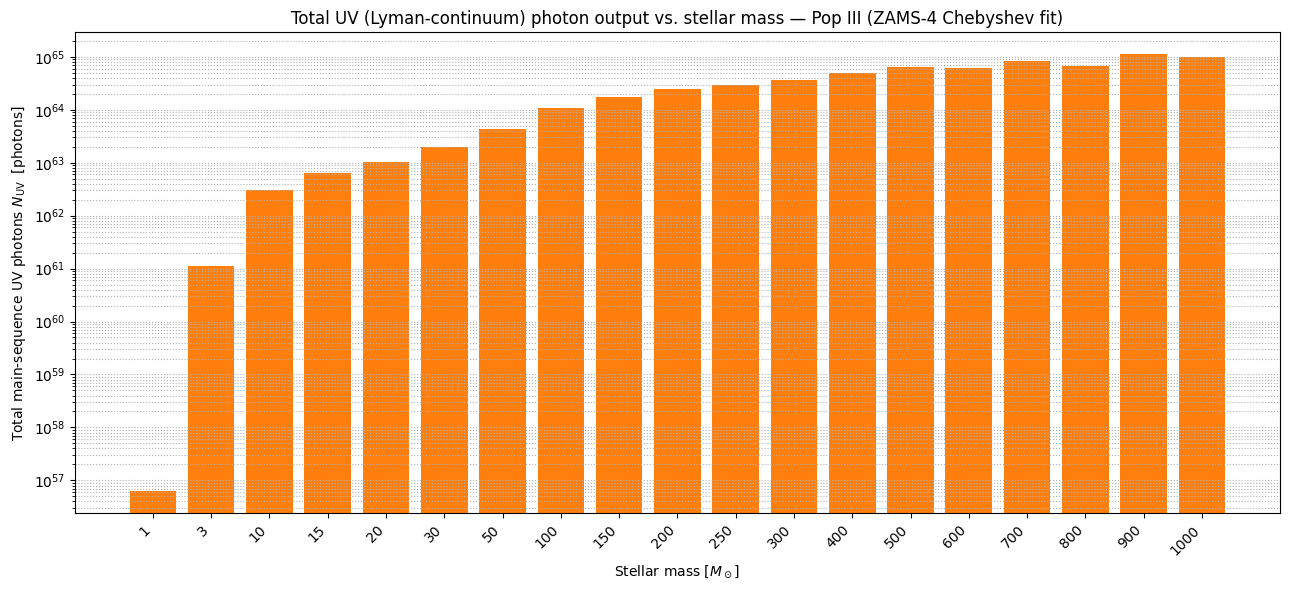

In [12]:
MASSES_TO_RUN = [1.0, 3.0, 10.0, 15.0, 20.0, 30.0, 50.0, 100.0, 150.0, 200.0, 250.0,
                 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0]
EXCLUDE_MASSES = {87.0}   # not present in MASSES_TO_RUN anyway; kept for symmetry with UV_output_total.ipynb

masses_to_run = [m for m in MASSES_TO_RUN if m not in EXCLUDE_MASSES]

N_UV_by_mass = {}
failed       = {}
for m in masses_to_run:
    try:
        N_UV_by_mass[m] = compute_total_UV_photons(m)
    except Exception as ex:
        failed[m] = f"{type(ex).__name__}: {ex}"
        print(f"  WARNING: mass={m:g} M_sun skipped — {failed[m]}")

print(f"Succeeded: {len(N_UV_by_mass)}/{len(masses_to_run)} masses")

masses_sorted = sorted(N_UV_by_mass)
N_values      = [N_UV_by_mass[m] for m in masses_sorted]

print("\nMass [M_sun]   N_UV [photons]")
for m, N in zip(masses_sorted, N_values):
    print(f"  {m:9.1f}    {N:.4e}")

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(masses_sorted))
ax.bar(x, N_values, color="tab:orange")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{m:g}" for m in masses_sorted], rotation=45, ha="right")
ax.set_xlabel(r"Stellar mass [$M_\odot$]")
ax.set_ylabel(r"Total main-sequence UV photons $N_{\rm UV}$  [photons]")
ax.set_title("Total UV (Lyman-continuum) photon output vs. stellar mass — Pop III (ZAMS-4 Chebyshev fit)")
ax.grid(True, axis="y", which="both", ls=":")
plt.tight_layout()
plt.show()


## Log-Log Trend: $N_{\rm UV}$ vs. Mass

Same data as the bar chart above, as a log-log line plot, plus the local power-law index
$d\ln N_{\rm UV}/d\ln M$ (centered finite difference in log-log space).


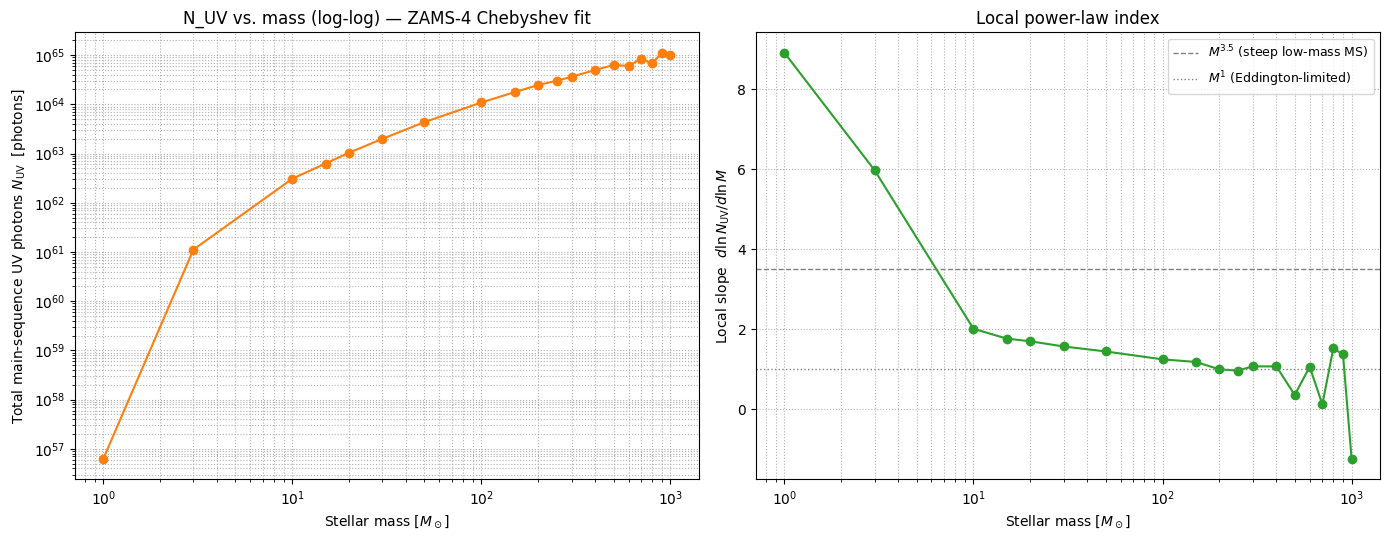

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].loglog(masses_sorted, N_values, marker="o", ls="-", color="tab:orange")
axes[0].set_xlabel(r"Stellar mass [$M_\odot$]")
axes[0].set_ylabel(r"Total main-sequence UV photons $N_{\rm UV}$  [photons]")
axes[0].set_title("N_UV vs. mass (log-log) — ZAMS-4 Chebyshev fit")
axes[0].grid(True, which="both", ls=":")

log_slope = np.gradient(np.log(N_values), np.log(masses_sorted))
axes[1].semilogx(masses_sorted, log_slope, marker="o", color="tab:green")
axes[1].axhline(3.5, color="gray", ls="--", lw=1, label=r"$M^{3.5}$ (steep low-mass MS)")
axes[1].axhline(1.0, color="gray", ls=":", lw=1, label=r"$M^{1}$ (Eddington-limited)")
axes[1].set_xlabel(r"Stellar mass [$M_\odot$]")
axes[1].set_ylabel(r"Local slope  $d\ln N_{\rm UV}/d\ln M$")
axes[1].set_title("Local power-law index")
axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()
